# SCT_DS_Task2
## Data Cleaning and Exploratory Data Analysis — Titanic Dataset

**Internship:** SkillCraft Technology  
**Task:** Data Cleaning and Exploratory Data Analysis  
**Dataset:** Titanic Passenger Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
# Fill missing Age values with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values with the most frequent value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin because it contains a large number of missing values
df.drop('Cabin', axis=1, inplace=True)

# Check missing values again
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
survival_by_sex = pd.crosstab(df['Sex'], df['Survived'])

print(survival_by_sex)

Survived    0    1
Sex               
female     81  233
male      468  109


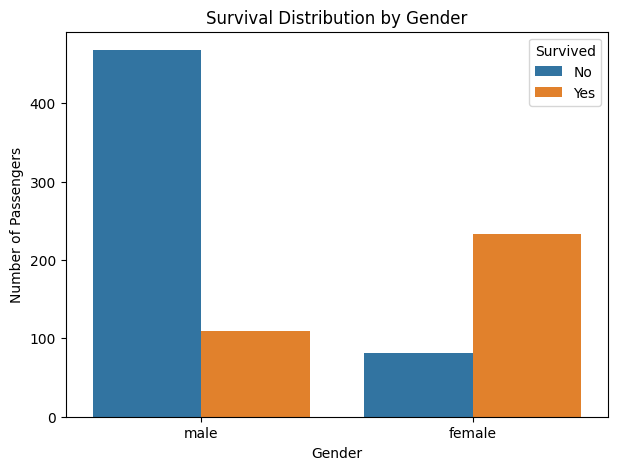

In [8]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Sex', hue='Survived')

plt.title('Survival Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])

plt.show()

In [9]:
survival_by_class = pd.crosstab(df['Pclass'], df['Survived'])

print(survival_by_class)

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


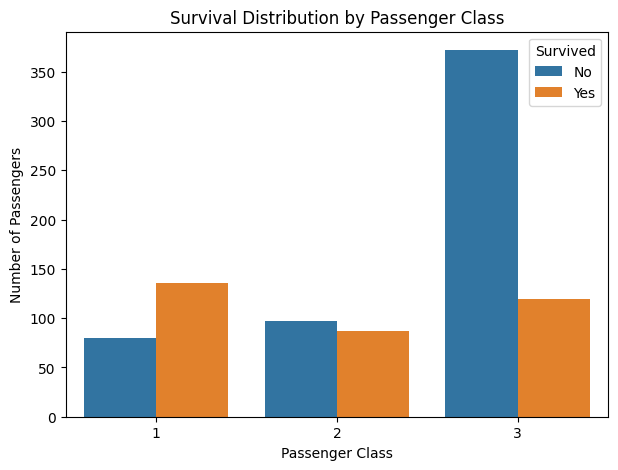

In [10]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Pclass', hue='Survived')

plt.title('Survival Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])

plt.show()

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='Age', bins=30, kde=True)

plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

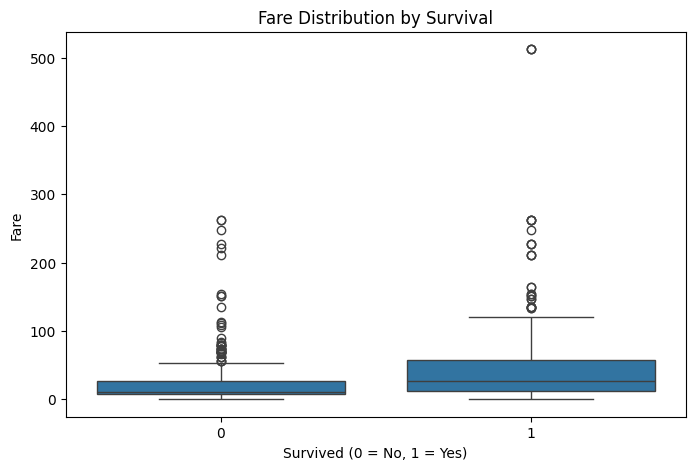

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Survived', y='Fare')

plt.title('Fare Distribution by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')

plt.show()

In [12]:
survival_rate = df['Survived'].mean() * 100

print(f"Overall Survival Rate: {survival_rate:.2f}%")

Overall Survival Rate: 38.38%


In [13]:
survival_percentage = pd.crosstab(
    df['Sex'],
    df['Survived'],
    normalize='index'
) * 100

print(survival_percentage.round(2))

Survived      0      1
Sex                   
female    25.80  74.20
male      81.11  18.89


## EDA Findings and Conclusion

### Key Findings

1. The overall survival rate was **38.38%**.
2. Gender had a strong relationship with survival. **74.20% of female passengers survived**, compared with **18.89% of male passengers**.
3. Passenger class was also associated with survival. **First-class passengers had more survivors than non-survivors**, while third-class passengers had substantially more non-survivors.
4. The age distribution showed that passengers covered a wide range of ages, with the largest concentration around young and middle-aged adults.
5. Passengers who survived generally had **higher fare values** than passengers who did not survive.

### Conclusion

The exploratory data analysis shows that survival on the Titanic was associated with several passenger characteristics, particularly **gender and passenger class**. Fare also showed a noticeable relationship with survival, while age provided an overview of the passenger population. Data cleaning was performed by handling missing Age and Embarked values and removing the Cabin column because of its large number of missing values.